Tiene una base de datos preprocesada ya.
1. Cargar los datos

In [5]:
import pandas as pd
import lxml
import numpy as np
import json
import seaborn as sns
import matplotlib.pyplot as plt

1. Cargamos el archivo diccionario

In [6]:
# Cargamos el archivo para tener los nombres reales
df_diccionario = pd.read_csv("BPS_pathologies_gen3.csv")

# Nos aseguramos de que el código BPS sea tratado como texto (string)
# y que tenga ceros a la izquierda (ej: '401' pasa a ser '0401')
df_diccionario['CODE_BPS'] = df_diccionario['CODE_BPS'].astype(str).str.zfill(4)

# Creamos un diccionario rápido de Python para traducir: { 'Código': 'Nombre en inglés' }
traductor_enfermedades = dict(zip(df_diccionario['CODE_BPS'], df_diccionario['BPS_PATHOLOGY']))

2. Cargamos los datos 

In [ ]:
nombre_archivo_json = "daae_generated_diabetes_patients_camda_gen3_preprocessed.json"

print("Cargando el archivo JSON... ")
with open(nombre_archivo_json, 'r') as f:
    datos_json = json.load(f)

registros_limpios = []

print("Procesando los historiales de los pacientes...")
for paciente_id, visitas in datos_json.items():
    # El sexo siempre está en la primera lista/visita
    codigo_sexo = visitas[0][0]
    sexo = "Mujer" if codigo_sexo == "2222" else "Hombre"
    
    # Recorremos el resto de visitas (de la segunda en adelante)
    # Recorremos el resto de visitas (de la segunda en adelante)
    for visita in visitas[1:]:
        # La edad DEBE empezar por 9 Y tener exactamente 4 caracteres (ej: "9070")
        edad_codigo = [c for c in visita if c.startswith("9") and len(str(c)) == 4]
        
        if edad_codigo:
            # Calculamos la edad real de forma segura
            edad = int(edad_codigo[0]) - 9000
            
            # Las enfermedades serán todo lo que NO sea el código de edad de 4 dígitos
            enfermedades = [c for c in visita if c != edad_codigo[0]]
            
            for enf in enfermedades:
                enf_4digitos = str(enf).zfill(4)
                nombre_enfermedad = traductor_enfermedades.get(enf_4digitos, f"Desconocido ({enf_4digitos})")
                
                registros_limpios.append({
                    "Paciente_ID": paciente_id,
                    "Sexo": sexo,
                    "Edad_Diagnostico": edad, # Ahora la edad será 100% real (entre 0 y 120)
                    "Codigo_Enfermedad": enf_4digitos,
                    "Nombre_Enfermedad": nombre_enfermedad
                })

# Convertimos la lista de registros en un DataFrame gigante de Pandas
df_pacientes = pd.DataFrame(registros_limpios)
print("¡Proceso completado! Tabla 'df_pacientes' creada con éxito.\n")

Cargando el archivo JSON... 
Procesando los historiales de los pacientes...
¡Proceso completado! Tabla 'df_pacientes' creada con éxito.



3. Análisis exploratiorio

In [23]:
print("--- MUESTRA DE LA TABLA PROCESADA ---")
print(df_pacientes.head(10))
print("\n" + "="*50 + "\n")

print("Número total de registros procesados:", len(df_pacientes))
print("Número total de pacientes únicos:", df_pacientes['Paciente_ID'].nunique())

--- MUESTRA DE LA TABLA PROCESADA ---
  Paciente_ID   Sexo  Edad_Diagnostico Codigo_Enfermedad  \
0           0  Mujer                70              0913   
1           0  Mujer                70              0401   
2           0  Mujer                72              1302   
3           0  Mujer                74              1401   
4           0  Mujer                75              0402   
5           0  Mujer                78              0507   
6           0  Mujer                80              0506   
7           0  Mujer                80              0212   
8           1  Mujer                47              1302   
9           1  Mujer                57              0913   

        Nombre_Enfermedad  
0            Hypertension  
1                Diabetes  
2   Arthrosis/spondylosis  
3  Chronic kidney disease  
4         Hyperlipidaemia  
5        Anxiety disorder  
6           Mood disorder  
7         Cervical cancer  
8   Arthrosis/spondylosis  
9            Hyperten

In [24]:
# 1. Conteo de Hombres vs Mujeres en tus datos
print("Distribucion de pacientes por sexo:")
print(df_pacientes['Sexo'].value_counts())
print ("\n")

# 2. Las 5 enfermedades más comunes en tu dataset
print("Top 5 enfermedades más comunes:")
top_5 = df_pacientes['Nombre_Enfermedad'].value_counts().head(5)
print(top_5)

Distribucion de pacientes por sexo:
Sexo
Hombre    2850830
Mujer     1475948
Name: count, dtype: int64


Top 5 enfermedades más comunes:
Nombre_Enfermedad
Diabetes                 899883
Hypertension             694489
Hyperlipidaemia          558800
Arthrosis/spondylosis    454434
Anxiety disorder         199217
Name: count, dtype: int64


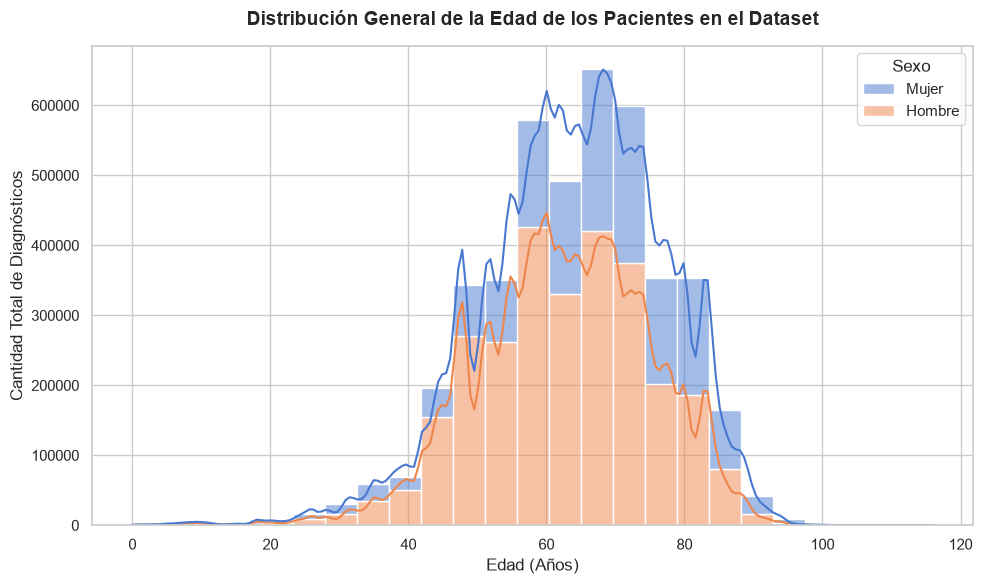

In [ ]:
plt.figure(figsize=(10, 6))

# 2. Elegimos un estilo visual limpio y bonito
sns.set_theme(style="whitegrid")

# 3. Creamos el gráfico de distribución de edad
# Usamos 'kde=True' para que dibuje la línea suave de la tendencia
# Usamos 'hue='Sexo'' para que pinte las barras de hombres y mujeres por separado y poder compararlos
sns.histplot(
    data=df_pacientes, 
    x='Edad_Diagnostico', 
    hue='Sexo', 
    multiple='stack',   # Apila las barras de hombre/mujer para ver también el total combinado
    bins=25,            # Número de barras en las que dividimos la edad
    kde=True,           # Dibuja la curva de densidad suave
    palette='muted'     # Paleta de colores suaves y profesionales
)

# 4. Añadimos las etiquetas de los ejes y el título en español
plt.title('Distribución General de la Edad de los Pacientes en el Dataset', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Edad (Años)', fontsize=12)
plt.ylabel('Cantidad Total de Diagnósticos', fontsize=12)

# 5. Ajustamos los márgenes para que no se corte nada y lo mostramos
plt.tight_layout()
plt.show()

